# Phase 3.0: Data Purification & Space-Time Consistency Pipeline

### Module Objective
The main goal of this notebook is to audit, structure, and export the final dataset that will feed our advanced predictive and econometric models in Phase 3. We will work directly with two main fact tables from our Data Warehouse: **`fact_market_balance`** and **`fact_trips`**. These tables contain the three official time-series of our ecosystem: Absolute Demand, Fulfilled Demand, and Latent Demand.

Using a modular pipeline, we will use **DuckDB** as a high-speed extraction engine to transfer our Apache Parquet assets into **Pandas in Python**. In this phase, we will ensure referential integrity, standardize data types, and most importantly, fix the continuity of the 5-minute chronological grids across the entire Uber H3 geographical matrix before running any predictive analysis.


In [10]:
# ENVIRONMENT INITIALIZATION & ANALYTICAL CLIENT PROVISIONING
# Objective: Load core data manipulation and visualization frameworks, and
# instantiate the high-performance in-memory DuckDB relational client.
# ==============================================================================

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Pandas environment to match professional IDE/VSC print layouts
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("[SYSTEM] Initializing clean-slate in-memory DuckDB client...")
# Opens a zero-latency memory connection to run high-speed SQL queries
con = duckdb.connect(database=':memory:')

# Lock the verified absolute infrastructure paths discovered in your audit
FACTS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/facts"
DIMENSIONS_FOLDER = "/kaggle/input/notebooks/marioocampo/spatial-etl-data-warehousing/data_warehouse/dimensions"

print("[SUCCESS] Analytical environment initialized. System variables secured.")


[SYSTEM] Initializing clean-slate in-memory DuckDB client...
[SUCCESS] Analytical environment initialized. System variables secured.


In [2]:
# DATA PIPELINE TRANSITION (PARQUET TO PANDAS DATAFRAMES)
# Objective: Stream the full data warehouse fact tables from disk straight
# into volatile RAM using conformed naming conventions for purification.

print("[DATA ENGINE] Streaming production warehouse facts into pure Python...")

# 1. Transition Fact Table Macro Supply and Demand Matrix
query_market = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_market_balance.parquet');"
df_fact_market_balance = con.execute(query_market).df()

# 2. Transition Fact Table Operational Trip Conversions Detail
query_trips = f"SELECT * FROM read_parquet('{FACTS_FOLDER}/fact_trips.parquet');"
df_fact_trips = con.execute(query_trips).df()

print("\n" + "="*80)
print("PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED")
print("="*80)
print(f" ✔ df_fact_market_balance | Shape: {df_fact_market_balance.shape[0]:,} rows x {df_fact_market_balance.shape[1]} columns")
print(f" ✔ df_fact_trips          | Shape: {df_fact_trips.shape[0]:,} rows x {df_fact_trips.shape[1]} columns")
print("-" * 80)
print("[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.")


[DATA ENGINE] Streaming production warehouse facts into pure Python...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PANDAS DATAFRAMES HISTORICAL SNAPSHOT ENGAGED
 ✔ df_fact_market_balance | Shape: 733,830 rows x 6 columns
 ✔ df_fact_trips          | Shape: 4,393,787 rows x 12 columns
--------------------------------------------------------------------------------
[SUCCESS] Data assets are now pure Python variables. DuckDB bridge closed.


In [3]:
# SCHEMA DATA AUDIT (MARKET BALANCE MATRIX)
# Objective: Inspect data types, non-null constraints, and memory footprints 
# to guarantee structural consistency over the full macro space-time matrix.

print("=== AUDITING DATA: df_fact_market_balance ===")
df_fact_market_balance.info()

# Cross-checking null values per column
null_report = df_fact_market_balance.isnull().sum()
print("\n -> Report of missing values (nulls) detected:")
print(null_report)


=== AUDITING DATA METADATA: df_fact_market_balance ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733830 entries, 0 to 733829
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp_5min            733830 non-null  datetime64[us]
 1   h3_cell                   733830 non-null  uint64        
 2   drivers_available_count   733830 non-null  int64         
 3   total_searches            733830 non-null  int64         
 4   total_abandoned_searches  733830 non-null  int64         
 5   avg_price_quoted          733830 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), uint64(1)
memory usage: 33.6 MB

 -> Formal report of missing values (nulls) detected:
timestamp_5min              0
h3_cell                     0
drivers_available_count     0
total_searches              0
total_abandoned_searches    0
avg_price_quoted            0
dtype: int64


In [4]:
# DESCRIPTIVE STATISTICS
# Objective: Extract statistical benchmarks, evaluate right-skewness indicators,
# and calculate kurtosis layers to justify statistical method selection.

print("STATISTICAL BENCHMARKS FOR DEMAND AND DROPOFF VARIABLES")
print("="*80)
# Official descriptive statistics for the key variables
print(df_fact_market_balance[['total_searches', 'total_abandoned_searches']].describe())
print("-" * 80)

# Calculation of asymmetry
df_skew = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].skew()

# Calculation of Kurtosis
df_kurt = df_fact_market_balance[['total_searches', 'total_abandoned_searches']].kurt()

print("\n=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===")
print(f" -> Total Searches Skewness : {df_skew['total_searches']:.4f}")
print(f" -> Abandoned Searches Skew : {df_skew['total_abandoned_searches']:.4f}")
print(f" -> Total Searches Kurtosis : {df_kurt['total_searches']:.4f} ")
print(f" -> Abandoned Searches Kurt : {df_kurt['total_abandoned_searches']:.4f}")


STATISTICAL BENCHMARKS FOR DEMAND AND DROPOFF VARIABLES
       total_searches  total_abandoned_searches
count   733830.000000             733830.000000
mean         7.231090                  1.243618
std          9.247322                  3.111498
min          0.000000                  0.000000
25%          1.000000                  0.000000
50%          4.000000                  0.000000
75%          9.000000                  1.000000
max         62.000000                 50.000000
--------------------------------------------------------------------------------

=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===
 -> Total Searches Skewness : 1.9572
 -> Abandoned Searches Skew : 6.0152
 -> Total Searches Kurtosis : 3.5969 
 -> Abandoned Searches Kurt : 45.6465


In [7]:
# MARKETPLACE CONSISTENCY RULES & REVENUE EFFICIENCY AUDIT
# Objective: Quantify the operational volume of idle supply fleet under zero
# demand windows, and verify algorithmic dynamic pricing integrity constraints.


# Wasted Supply using .shape and .sum()
zero_demand_blocks = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0].shape[0]
accumulated_idle_supply = df_fact_market_balance[df_fact_market_balance['total_searches'] == 0]['drivers_available_count'].sum()
total_monthly_supply = df_fact_market_balance['drivers_available_count'].sum()

idle_percentage = (accumulated_idle_supply / total_monthly_supply) * 100

# Verification of Phantom Prices in blocks with zero demand intents
phantom_prices_count = df_fact_market_balance[(df_fact_market_balance['total_searches'] == 0) & (df_fact_market_balance['avg_price_quoted'] != 0)].shape[0]

print("="*80)
print("OPERATIONAL REPORT: MARKETPLACE INTEGRITY & EFFICIENCY")
print("="*80)
print(f" -> 5-min intervals with zero searches in Reforma : {zero_demand_blocks:,} blocks.")
print(f" -> Drivers waiting in empty windows (Idle Supply): {accumulated_idle_supply:,} instances.")
print(f" -> Total capacity offered during the month (March): {total_monthly_supply:,} instances.")
print(f" -> Real percentage of idle / dead supply supply  : {idle_percentage:.2f}% of monthly supply.")
print("-" * 80)
print(f" -> Records with Phantom Prices detected         : {phantom_prices_count} anomalies.")
print("="*80)
if phantom_prices_count == 0:
    print("[INTEGRITY VERIFIED] The Surge Pricing algorithm responds logically to the market.")


OPERATIONAL REPORT: MARKETPLACE INTEGRITY & EFFICIENCY
 -> 5-min intervals with zero searches in Reforma : 140,454 blocks.
 -> Drivers waiting in empty windows (Idle Supply): 2,044,023 instances.
 -> Total capacity offered during the month (March): 29,690,592 instances.
 -> Real percentage of idle / dead supply supply  : 6.88% of monthly supply.
--------------------------------------------------------------------------------
 -> Records with Phantom Prices detected         : 0 anomalies.
[INTEGRITY VERIFIED] The Surge Pricing algorithm responds logically to the market.


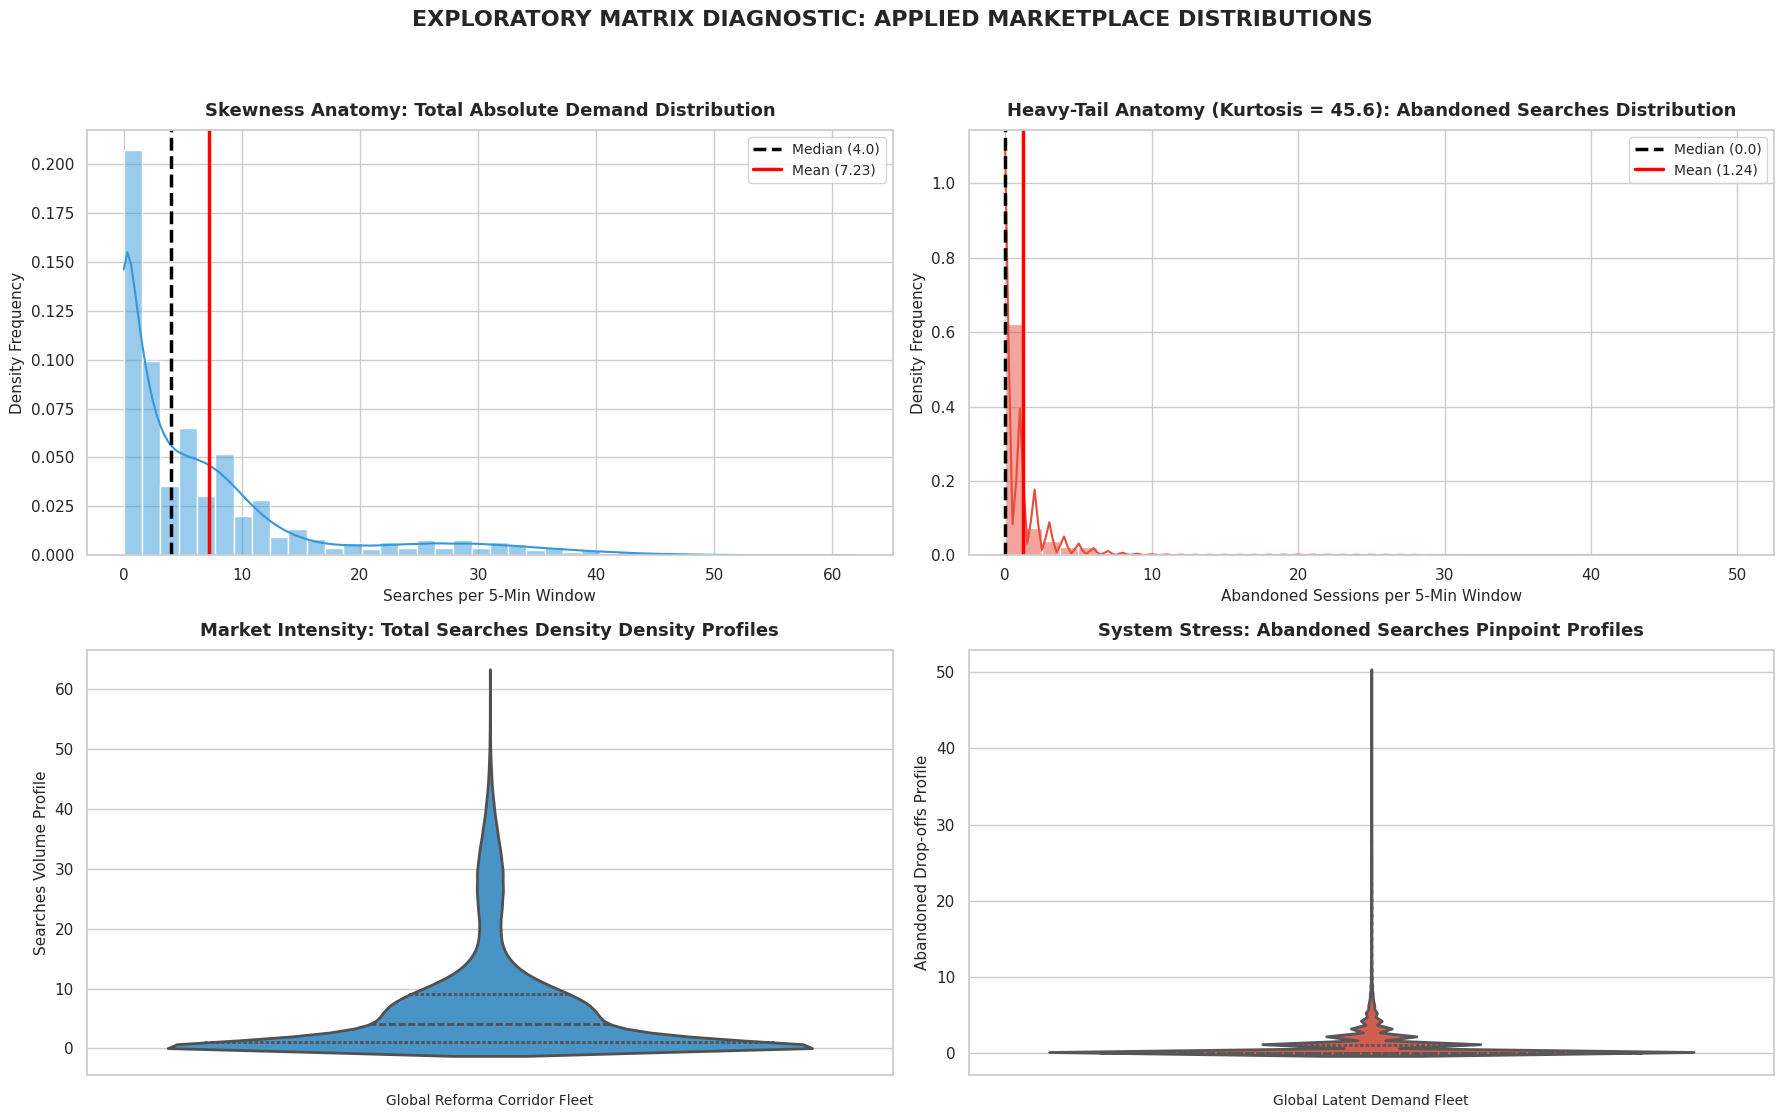

In [8]:
# DATA DENSITY & VIOLIN PLOT MATRIX
# Objective: Deploy a comprehensive 2x2 analytical plot grid combining histograms 
# and violin charts to capture skewness and distribution.
# 

# Establish the high-end grid theme parameters
sns.set_theme(style="whitegrid", context="notebook")

# Initialize the 2x2 analytical layout matrix grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# ROW 1, COL 1: HISTOGRAM - TOTAL DEMAND (Searches)
# ------------------------------------------------------------------------------
sns.histplot(data=df_fact_market_balance, x='total_searches', ax=ax1, kde=True, color='#3498db', bins=40, stat="density")
ax1.axvline(df_fact_market_balance['total_searches'].median(), color='black', linestyle='--', linewidth=2.5, label=f"Median ({df_fact_market_balance['total_searches'].median()})")
ax1.axvline(df_fact_market_balance['total_searches'].mean(), color='red', linestyle='-', linewidth=2.5, label=f"Mean ({df_fact_market_balance['total_searches'].mean():.2f})")
ax1.set_title('Skewness Anatomy: Total Absolute Demand Distribution', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Searches per 5-Min Window', fontsize=11)
ax1.set_ylabel('Density Frequency', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 1, COL 2: HISTOGRAM - LATENT UNSATISFIED DEMAND (Abandoned)
# ------------------------------------------------------------------------------
sns.histplot(data=df_fact_market_balance, x='total_abandoned_searches', ax=ax2, kde=True, color='#e74c3c', bins=40, stat="density")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].median(), color='black', linestyle='--', linewidth=2.5, label=f"Median ({df_fact_market_balance['total_abandoned_searches'].median()})")
ax2.axvline(df_fact_market_balance['total_abandoned_searches'].mean(), color='red', linestyle='-', linewidth=2.5, label=f"Mean ({df_fact_market_balance['total_abandoned_searches'].mean():.2f})")
ax2.set_title('Heavy-Tail Anatomy (Kurtosis = 45.6): Abandoned Searches Distribution', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Abandoned Sessions per 5-Min Window', fontsize=11)
ax2.set_ylabel('Density Frequency', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 2, COL 1: VIOLIN PLOT - TOTAL DEMAND (Searches)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_fact_market_balance, y='total_searches', ax=ax3, color='#3498db', inner="quartile", linewidth=2)
ax3.set_title('Market Intensity: Total Searches Density Density Profiles', fontsize=13, fontweight='bold', pad=10)
ax3.set_ylabel('Searches Volume Profile', fontsize=11)
ax3.set_xlabel('Global Reforma Corridor Fleet', fontsize=10)

# ------------------------------------------------------------------------------
# ROW 2, COL 2: VIOLIN PLOT - LATENT UNSATISFIED DEMAND (Abandoned)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_fact_market_balance, y='total_abandoned_searches', ax=ax4, color='#e74c3c', inner="quartile", linewidth=2)
ax4.set_title('System Stress: Abandoned Searches Pinpoint Profiles', fontsize=13, fontweight='bold', pad=10)
ax4.set_ylabel('Abandoned Drop-offs Profile', fontsize=11)
ax4.set_xlabel('Global Latent Demand Fleet', fontsize=10)

# Configuration parameters over the canvas
plt.suptitle('EXPLORATORY MATRIX DIAGNOSTIC: APPLIED MARKETPLACE DISTRIBUTIONS', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


In [11]:
# SCHEMA DATA AUDIT (TRIPS)
# Objective: Inspect data types, non-null constraints 
# to guarantee structural consistency

print("=== AUDITING DATA: df_fact_trips ===")
df_fact_trips.info()

# Cross-checking null values per column
null_report_trips = df_fact_trips.isna().sum()
print("\n -> Formal report of missing values detected:")
print(null_report_trips)

=== AUDITING DATA: df_fact_trips ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4393787 entries, 0 to 4393786
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id_user           object        
 1   id_driver         object        
 2   timestamp_5min    datetime64[us]
 3   h3_cell           uint64        
 4   id_trip           object        
 5   id_search         object        
 6   trip_status       object        
 7   price_quoted      float64       
 8   price_base        float64       
 9   duration_seconds  float64       
 10  is_completed      int32         
 11  is_canceled       int32         
dtypes: datetime64[us](1), float64(3), int32(2), object(5), uint64(1)
memory usage: 368.7+ MB

 -> Formal report of missing values (nulls) detected:
id_user                   0
id_driver                 0
timestamp_5min            0
h3_cell                   0
id_trip                   0
id_search                 0
t

In [12]:
# DESCRIPTIVE STATISTICS (TRIPS CONVERSION MATRIX)
# Objective: Extract statistical benchmarks, evaluate skewness indicators,
# and calculate kurtosis to evaluate binary column behavior.


# FORCE PANDAS TO DROP SCIENTIFIC NOTATION: Enforces clean float decimal styling
pd.options.display.float_format = '{:,.4f}'.format

print("="*80)
print("STATISTICAL BENCHMARKS FOR TRIPS COMPLETED")
print("="*80)
# Descriptive statistics for the core binary conversion variable
print(df_fact_trips['is_completed'].describe())
print("-" * 80)

# Calculation of asymmetry (Fisher Skewness)
df_skew = df_fact_trips['is_completed'].skew()

# Calculation of tails weight (Fisher Kurtosis)
df_kurt = df_fact_trips['is_completed'].kurt()

print("\n=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===")
print(f" -> Trips Completed Skewness : {df_skew:.4f}")
print(f" -> Trips Completed Kurtosis : {df_kurt:.4f}")
print("="*80)


STATISTICAL BENCHMARKS FOR TRIPS COMPLETED
count   4,393,787.0000
mean            0.7500
std             0.4330
min             0.0000
25%             1.0000
50%             1.0000
75%             1.0000
max             1.0000
Name: is_completed, dtype: float64
--------------------------------------------------------------------------------

=== MATHEMATICAL DISTRIBUTION DIAGNOSTIC ===
 -> Trips Completed Skewness : -1.1549
 -> Trips Completed Kurtosis : -0.6663


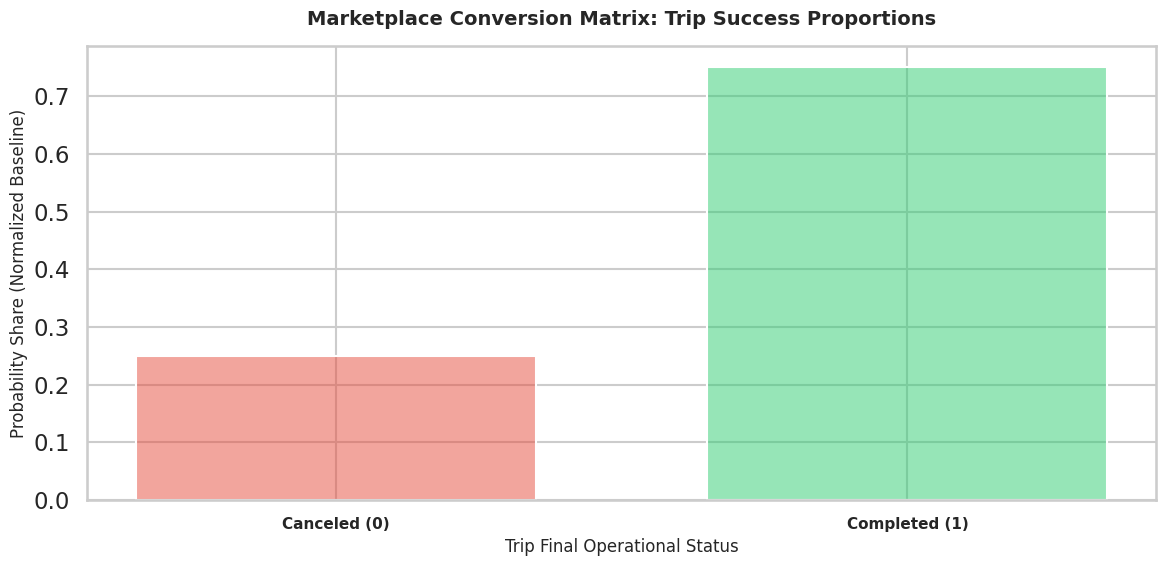

In [14]:
# ==============================================================================
# BINARY PROBABILITY DISTRIBUTION DIAGNOSTIC (TRIPS CONVERSION LAYER)
# Objective: Deploy a clean probability distribution matrix to analyze binary 
# conversion success rates, correcting all legacy aesthetic Seaborn warnings.
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Re-enforce our clean whitegrid style parameters
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 6))

# FIXED SEABORN COUNTPLOT: Mapping 'is_completed' to 'hue' and setting 'legend=False'
# This explicitly eliminates the palette deprecation FutureWarning and the ticklabels UserWarning
sns.histplot(
    data=df_fact_trips,
    x='is_completed',
    hue='is_completed',
    stat='probability', # Scales the Y-axis to show pure proportional probabilities (0.0 to 1.0)
    discrete=True,      # Tells Seaborn to strictly treat the axis as binary integer steps (0 and 1)
    shrink=0.7,         # Adds a sleek spacing separation between both blocks
    palette=['#e74c3c', '#2ecc71'], # Red for Canceled (0) | Green for Completed (1)
    legend=False,
    ax=ax
)

# Set custom explicit fixed ticks to prevent axis compression warnings
ax.set_xticks([0, 1])
ax.set_xticklabels(['Canceled (0)', 'Completed (1)'], fontsize=11, fontweight='bold')

# Configure clean corporate B1/B2 English metadata annotations
ax.set_title('Marketplace Conversion Matrix: Trip Success Proportions', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Trip Final Operational Status', fontsize=12)
ax.set_ylabel('Probability Share (Normalized Baseline)', fontsize=12)

plt.tight_layout()
plt.show()


In [15]:
df_fact_trips.head()

,id_user,id_driver,timestamp_5min,h3_cell,id_trip,id_search,trip_status,price_quoted,price_base,duration_seconds,is_completed,is_canceled
0,USR_055514,DRV_02475,2026-03-23 07:05:00,618287667719700479,TRP_3145729,SCH_3924124,completed,61.5800,61.5800,184.4509,1,0
1,USR_093206,DRV_00016,2026-03-23 07:05:00,618287667203538943,TRP_3145730,SCH_3880291,completed,61.1200,61.1200,181.2905,1,0
2,USR_040324,DRV_02567,2026-03-23 07:05:00,618287667715768319,TRP_3145731,SCH_3777658,completed,103.7400,103.7400,477.0575,1,0
3,USR_079217,DRV_04417,2026-03-23 07:05:00,618287667715506175,TRP_3145732,SCH_3799208,completed,61.9300,61.9300,186.9296,1,0
4,USR_049950,DRV_00444,2026-03-23 07:05:00,618287667717865471,TRP_3145733,SCH_3916802,completed,89.1200,89.1200,180.0000,1,0
